In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.pyplot as mdates

In [2]:
visits_log = pd.read_csv('/datasets/visits_log_us.csv')
orders_log = pd.read_csv('/datasets/orders_log_us.csv')
costs = pd.read_csv('/datasets/costs_us.csv')
# se leen los datasets para poder trabajar con ellos 

In [3]:
display(visits_log.info())
display(orders_log.info())
display(costs.info())
# se imprime la info de cada dataset pára ver con que informacion se va a trabajar 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB


None

In [4]:
display(visits_log.head())
display(orders_log.head())
display(costs.head())

,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


In [5]:
visits_log.isnull().sum()
#se revisa que el DS visits_log no tenga null

Device       0
End Ts       0
Source Id    0
Start Ts     0
Uid          0
dtype: int64

In [6]:
orders_log.isnull().sum()
#se revisa que el ds orders_log no tenga null

Buy Ts     0
Revenue    0
Uid        0
dtype: int64

In [7]:
costs.isnull().sum()
#se revisa que el ds costs no tenga null

source_id    0
dt           0
costs        0
dtype: int64

In [8]:
visits_log['End Ts'] = pd.to_datetime(visits_log['End Ts'])
visits_log['Start Ts'] = pd.to_datetime(visits_log['Start Ts'])
orders_log['Buy Ts'] = pd.to_datetime(orders_log['Buy Ts'])
costs['dt'] = pd.to_datetime(costs['dt'])
#la primera vez que usamos el .info vimos que las columnas con fechas tenian un  tipo de dato incorrecto
#se hizo el cambio de dato usando .to_datetime

In [9]:
display(visits_log.info())
display(orders_log.info())
display(costs.info())
#se vuelve a usar el.info en cada DS para verificar el cambio de tipo de dato en cada columna

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  object        
 1   End Ts     359400 non-null  datetime64[ns]
 2   Source Id  359400 non-null  int64         
 3   Start Ts   359400 non-null  datetime64[ns]
 4   Uid        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Buy Ts   50415 non-null  datetime64[ns]
 1   Revenue  50415 non-null  float64       
 2   Uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB


None

In [10]:
visits_log['date'] = visits_log['Start Ts'].dt.date
#Se crea una columna de fecha para agrupar los datos sin hora 
daily_users = visits_log.groupby('date')['Uid'].nunique()
#Se busca que los identificadores diarios solo se cuenten uno por usuario y no se repitan
print('Usuarios unicos por día', daily_users.head(10))
#se imprime la informacion de cuantas cuentas unicas entraron por día 

Usuarios unicos por día date
2017-06-01    605
2017-06-02    608
2017-06-03    445
2017-06-04    476
2017-06-05    820
2017-06-06    797
2017-06-07    699
2017-06-08    868
2017-06-09    695
2017-06-10    350
Name: Uid, dtype: int64


In [11]:
#Aquí haremos la cuenta de usuarios unicos por semana 
visits_log['week'] = visits_log['Start Ts'].dt.to_period('W')
#Al igual que arriba sebuscan los ID de usuario se cuente uno por usuario y no se repita por mes
weekly_users = visits_log.groupby('week')['Uid'].nunique()

#Haremos la cuenta de usuarios unicos por mes
visits_log['month'] = visits_log['Start Ts'].dt.to_period('M')
#Al igual que arriba se buscara lo mismo pero ahora mensual 
monthly_users = visits_log.groupby('month')['Uid'].nunique()

In [12]:
#Se imprimira la informacion de cuantos usuarios unicos hubo por semana 
print('Usuarios unicos por semana', weekly_users.head())
#Se imprimira la info de cuentas por mes 
print("")
print('Usuarios unicos por mes', monthly_users)


Usuarios unicos por semana week
2017-05-29/2017-06-04    2021
2017-06-05/2017-06-11    4129
2017-06-12/2017-06-18    2812
2017-06-19/2017-06-25    2878
2017-06-26/2017-07-02    3064
Freq: W-SUN, Name: Uid, dtype: int64

Usuarios unicos por mes month
2017-06    13259
2017-07    14183
2017-08    11631
2017-09    18975
2017-10    29692
2017-11    32797
2017-12    31557
2018-01    28716
2018-02    28749
2018-03    27473
2018-04    21008
2018-05    20701
Freq: M, Name: Uid, dtype: int64


In [13]:
#Se imprimira la informacion de cuantos usuarios unicos hubo por semana 
print('Usuarios unicos por semana', weekly_users.head())
#Se imprimira la info de cuentas por mes 
print("")
print('Usuarios unicos por mes', monthly_users)


Usuarios unicos por semana week
2017-05-29/2017-06-04    2021
2017-06-05/2017-06-11    4129
2017-06-12/2017-06-18    2812
2017-06-19/2017-06-25    2878
2017-06-26/2017-07-02    3064
Freq: W-SUN, Name: Uid, dtype: int64

Usuarios unicos por mes month
2017-06    13259
2017-07    14183
2017-08    11631
2017-09    18975
2017-10    29692
2017-11    32797
2017-12    31557
2018-01    28716
2018-02    28749
2018-03    27473
2018-04    21008
2018-05    20701
Freq: M, Name: Uid, dtype: int64


In [14]:
print(type(daily_users))
print(daily_users.head())

<class 'pandas.core.series.Series'>
date
2017-06-01    605
2017-06-02    608
2017-06-03    445
2017-06-04    476
2017-06-05    820
Name: Uid, dtype: int64


(array([17348., 17410., 17471., 17532., 17591., 17652.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

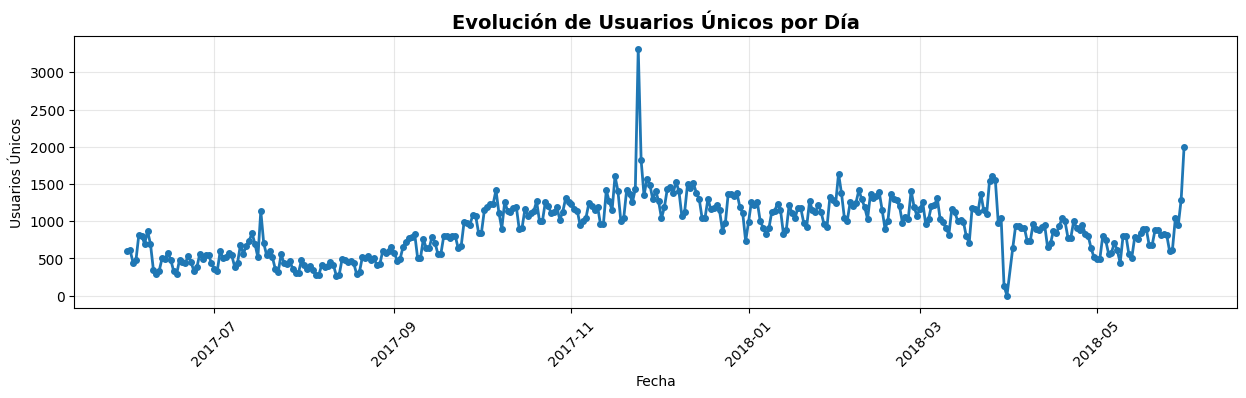

In [15]:
#Se crearan graficas de linea, para interpretar mejor cada resultado, por día, semana y mes
#Grafica por día 
plt.figure(figsize=(15, 12))
plt.subplot(3, 1, 1)
plt.plot(daily_users.index, daily_users.values, marker='o', linewidth=2, markersize=4)
plt.title('Evolución de Usuarios Únicos por Día', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Usuarios Únicos')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45) 

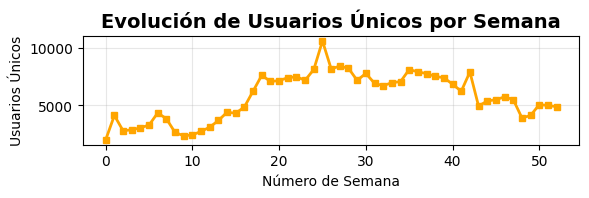

In [16]:
#Se creara la grafica semana

plt.subplot(3, 1, 2)
plt.plot(weekly_users.values, marker='s', linewidth=2, markersize=4, color='orange')
plt.title('Evolución de Usuarios Únicos por Semana', fontsize=14, fontweight='bold')
plt.xlabel('Número de Semana')
plt.ylabel('Usuarios Únicos')
plt.grid(True, alpha=0.3);

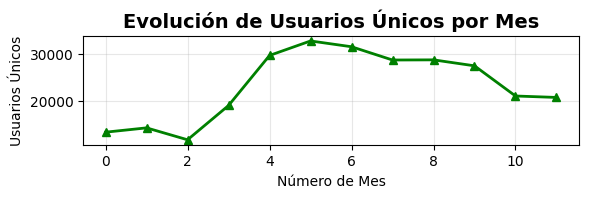

In [17]:
#Se hara la grafica mensiual 
plt.subplot(3, 1, 3)
plt.plot(monthly_users.values, marker='^', linewidth=2, markersize=6, color='green')
plt.title('Evolución de Usuarios Únicos por Mes', fontsize=14, fontweight='bold')
plt.xlabel('Número de Mes')
plt.ylabel('Usuarios Únicos')
plt.grid(True, alpha=0.3)

In [18]:
# se hizo el conteo de sesiones por día, en este caso no se necesitaron cuentas unicas
daily_visits = visits_log.groupby('date')['Uid'].count()
#se imprimira esa informacion
display('Numero de sesiones por día', daily_visits.head())

'Numero de sesiones por día'

date
2017-06-01    664
2017-06-02    658
2017-06-03    477
2017-06-04    510
2017-06-05    893
Name: Uid, dtype: int64

In [19]:
#se calculara el tiempo de duracion de cada sesion, se crea una columna para que contenga ese resultado
visits_log['session_duration'] = visits_log['End Ts'] - visits_log['Start Ts']
print(visits_log.head())

    Device              End Ts  Source Id            Start Ts  \
0    touch 2017-12-20 17:38:00          4 2017-12-20 17:20:00   
1  desktop 2018-02-19 17:21:00          2 2018-02-19 16:53:00   
2    touch 2017-07-01 01:54:00          5 2017-07-01 01:54:00   
3  desktop 2018-05-20 11:23:00          9 2018-05-20 10:59:00   
4  desktop 2017-12-27 14:06:00          3 2017-12-27 14:06:00   

                    Uid        date                   week    month  \
0  16879256277535980062  2017-12-20  2017-12-18/2017-12-24  2017-12   
1    104060357244891740  2018-02-19  2018-02-19/2018-02-25  2018-02   
2   7459035603376831527  2017-07-01  2017-06-26/2017-07-02  2017-07   
3  16174680259334210214  2018-05-20  2018-05-14/2018-05-20  2018-05   
4   9969694820036681168  2017-12-27  2017-12-25/2017-12-31  2017-12   

  session_duration  
0  0 days 00:18:00  
1  0 days 00:28:00  
2  0 days 00:00:00  
3  0 days 00:24:00  
4  0 days 00:00:00  


In [20]:
# se calcula cuantas visitas tiene cada usuario
visits_per_user = visits_log.groupby('Uid').size()
print('Visitas por usuario', visits_per_user.head(10))

Visitas por usuario Uid
11863502262781     1
49537067089222     1
297729379853735    1
313578113262317    3
325320750514679    2
397399764396656    1
407573351275847    1
498809019029702    1
526778907996220    4
577434573913691    2
dtype: int64


In [21]:
# se identificara que usuarios tiene mas de una visita 
returning_users = visits_per_user[visits_per_user > 1]
print('Usuarios que regresar', returning_users.head(10))

Usuarios que regresar Uid
313578113262317     3
325320750514679     2
526778907996220     4
577434573913691     2
1260655184775459    4
1575281904278712    2
2464366381792757    2
2471247936243530    3
2551852515556206    2
2892676062023446    3
dtype: int64


In [22]:
#Se calcula el total de usuarios unicos
total_users = len(visits_per_user)
print('total de usuarios unicos', visits_per_user)
#se calcula el porcentaje de usuarios que regresan
percentage_returning = (len(returning_users) / total_users) * 100
print(f"Porcentaje de usuarios que regresan: {percentage_returning:.2f}%")

total de usuarios unicos Uid
11863502262781          1
49537067089222          1
297729379853735         1
313578113262317         3
325320750514679         2
                       ..
18446403737806311543    1
18446424184725333426    1
18446556406699109058    1
18446621818809592527    2
18446676030785672386    1
Length: 228169, dtype: int64
Porcentaje de usuarios que regresan: 22.85%


Ventas: 
Se hara el analices de ventas por usuario, cuando empiezan a comprar, cuandots pedidos se hacen por periodo de tiempo, tamaño promedio de compra y el LTV 

In [23]:
#se calculara la primera visita de cada usuario 
first_visit = visits_log.groupby('Uid')['Start Ts'].min().reset_index()
first_visit.columns = ['Uid', 'first_visit_date']

#Con la info anterior se calculara cuando es la primera compra de cada usuario
first_purchase = orders_log.groupby('Uid')['Buy Ts'].min().reset_index()
first_purchase.columns = ['Uid', 'first_purchase_date']

#se imprime la informacion obtenida por cada linea, tanto la priemra visita como la primera compra
print('Primera visita por usuario:')
print(first_visit.head())
print('')
print('Primera compra por usuario:')
print(first_purchase.head())

Primera visita por usuario:
               Uid    first_visit_date
0   11863502262781 2018-03-01 17:27:00
1   49537067089222 2018-02-06 15:55:00
2  297729379853735 2017-06-07 18:47:00
3  313578113262317 2017-09-18 22:49:00
4  325320750514679 2017-09-30 14:29:00

Primera compra por usuario:
                Uid first_purchase_date
0   313578113262317 2018-01-03 21:51:00
1  1575281904278712 2017-06-03 10:13:00
2  2429014661409475 2017-10-11 18:33:00
3  2464366381792757 2018-01-28 15:54:00
4  2551852515556206 2017-11-24 10:14:00


In [24]:
#Uniremos la primera visita y la primera compra con .merge
conversion_data = first_visit.merge(first_purchase, on='Uid', how='inner')
print(f"Usuarios que visitaron: {len(first_visit)}")
print(f"Usuarios que compraron: {len(first_purchase)}")
print("")
print(conversion_data.head())

Usuarios que visitaron: 228169
Usuarios que compraron: 36523

                Uid    first_visit_date first_purchase_date
0   313578113262317 2017-09-18 22:49:00 2018-01-03 21:51:00
1  1575281904278712 2017-06-03 10:13:00 2017-06-03 10:13:00
2  2429014661409475 2017-10-11 17:14:00 2017-10-11 18:33:00
3  2464366381792757 2018-01-27 20:10:00 2018-01-28 15:54:00
4  2551852515556206 2017-11-24 10:14:00 2017-11-24 10:14:00


In [25]:
# se calcularan los días de conversión, cuantos dias ocurrieron entre la visita y la priemra compra
conversion_data['days_to_conversion'] = (conversion_data['first_purchase_date'] - conversion_data['first_visit_date']).dt.days
print(conversion_data)

                        Uid    first_visit_date first_purchase_date  \
0           313578113262317 2017-09-18 22:49:00 2018-01-03 21:51:00   
1          1575281904278712 2017-06-03 10:13:00 2017-06-03 10:13:00   
2          2429014661409475 2017-10-11 17:14:00 2017-10-11 18:33:00   
3          2464366381792757 2018-01-27 20:10:00 2018-01-28 15:54:00   
4          2551852515556206 2017-11-24 10:14:00 2017-11-24 10:14:00   
...                     ...                 ...                 ...   
36518  18445147675727495770 2017-08-20 13:30:00 2017-11-24 09:03:00   
36519  18445407535914413204 2017-09-22 23:48:00 2017-09-22 23:55:00   
36520  18445601152732270159 2017-08-07 11:51:00 2018-03-26 22:54:00   
36521  18446156210226471712 2017-11-07 10:01:00 2018-02-18 19:34:00   
36522  18446167067214817906 2017-10-17 10:05:00 2017-10-17 10:16:00   

       days_to_conversion  
0                     106  
1                       0  
2                       0  
3                       0  
4      

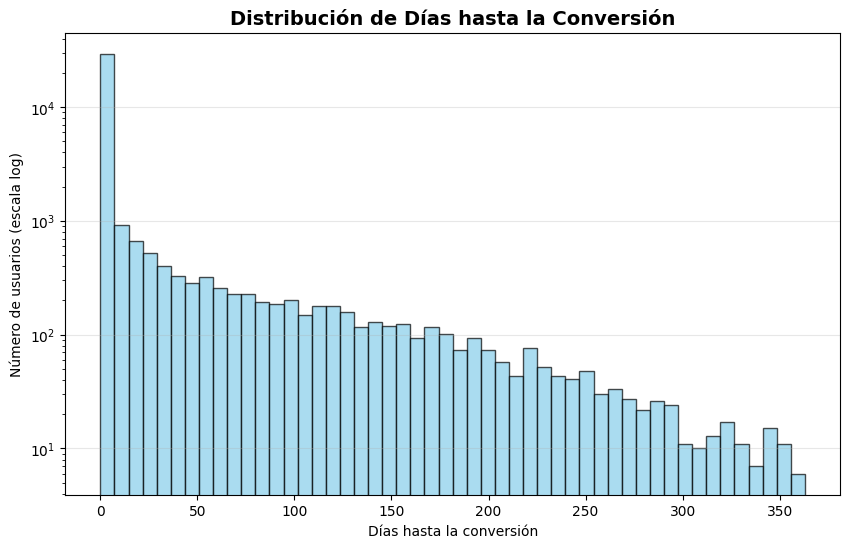

In [26]:
# Se graficara la distribucion de days_to_conversion
# se uso una escala logaritmica para que los datos de conversion se pudieran apreciar mejor
# ya que los datos de 0 eran muy altos y hacia que los otros datos no se pudieran ver
plt.figure(figsize=(10, 6))
plt.hist(conversion_data['days_to_conversion'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribución de Días hasta la Conversión', fontsize=14, fontweight='bold')
plt.xlabel('Días hasta la conversión')
plt.ylabel('Número de usuarios (escala log)')
plt.yscale('log') 
plt.grid(axis='y', alpha=0.3)
plt.show()

In [27]:
#se crearan las categorías de conversion 
def categorize_conversion(days):
    if days == 0:
        return 'Conversion 0d'
    elif days == 1:
        return 'Conversion 1d'
    elif days <= 7:
        return 'Conversion 2-7d'
    elif days <= 30:
        return 'Conversion 8-30d'
    else:
        return 'Conversion 30d+'
conversion_data['conversion_category'] = conversion_data['days_to_conversion'].apply(categorize_conversion)
conversion_distribution = conversion_data['conversion_category'].value_counts().sort_index()
print("Distribución de conversiones:")
print(conversion_distribution)
print("Porcentajes:")
print((conversion_distribution / len(conversion_data) * 100).round(2))

Distribución de conversiones:
Conversion 0d       26363
Conversion 1d        1011
Conversion 2-7d      2069
Conversion 30d+      4902
Conversion 8-30d     2178
Name: conversion_category, dtype: int64
Porcentajes:
Conversion 0d       72.18
Conversion 1d        2.77
Conversion 2-7d      5.66
Conversion 30d+     13.42
Conversion 8-30d     5.96
Name: conversion_category, dtype: float64


In [28]:
#se comenzara a analizar por cohortes
first_visit_source = visits_log.groupby('Uid').agg({
    'Start Ts': 'min',
    'Source Id': 'first'
}).reset_index()
first_visit_source.columns = ['Uid', 'first_visit_date', 'first_visit_source']

# Hacer merge con conversion_data
conversion_with_source = conversion_data.merge(
    first_visit_source[['Uid', 'first_visit_source']], 
    on='Uid', 
    how='left'
)

print("Verificación:")
print(conversion_with_source.head())

Verificación:
                Uid    first_visit_date first_purchase_date  \
0   313578113262317 2017-09-18 22:49:00 2018-01-03 21:51:00   
1  1575281904278712 2017-06-03 10:13:00 2017-06-03 10:13:00   
2  2429014661409475 2017-10-11 17:14:00 2017-10-11 18:33:00   
3  2464366381792757 2018-01-27 20:10:00 2018-01-28 15:54:00   
4  2551852515556206 2017-11-24 10:14:00 2017-11-24 10:14:00   

   days_to_conversion conversion_category  first_visit_source  
0                 106     Conversion 30d+                   2  
1                   0       Conversion 0d                  10  
2                   0       Conversion 0d                   3  
3                   0       Conversion 0d                   5  
4                   0       Conversion 0d                   5  


In [29]:
# se continua el analisis de cohortes que se empezó en la linea anterior 
conversion_by_source = conversion_with_source.groupby(['first_visit_source', 'conversion_category']).size().unstack(fill_value=0)
# se calcula porcentajes por canal 
conversion_percentages = conversion_by_source.div(conversion_by_source.sum(axis=1), axis=0) * 100

print("Conversión por canal (porcentajes):")
print(conversion_percentages.round(2))
print("")
print("Canales con mayor conversión inmediata (0d):")
print(conversion_percentages['Conversion 0d'].sort_values(ascending=False))

# se imprimira el volumen total por canal 
print("Volumen total de conversiones por canal:")
print(conversion_by_source.sum(axis=1).sort_values(ascending=False))

Conversión por canal (porcentajes):
conversion_category  Conversion 0d  Conversion 1d  Conversion 2-7d  \
first_visit_source                                                   
1                            70.00           3.93             7.53   
2                            63.47           3.54             7.15   
3                            75.02           2.42             4.94   
4                            72.12           2.58             5.70   
5                            77.47           2.25             4.74   
7                           100.00           0.00             0.00   
9                            56.75           3.04             5.87   
10                           77.20           3.22             4.83   

conversion_category  Conversion 30d+  Conversion 8-30d  
first_visit_source                                      
1                              11.92              6.63  
2                              17.65              8.19  
3                              12.4

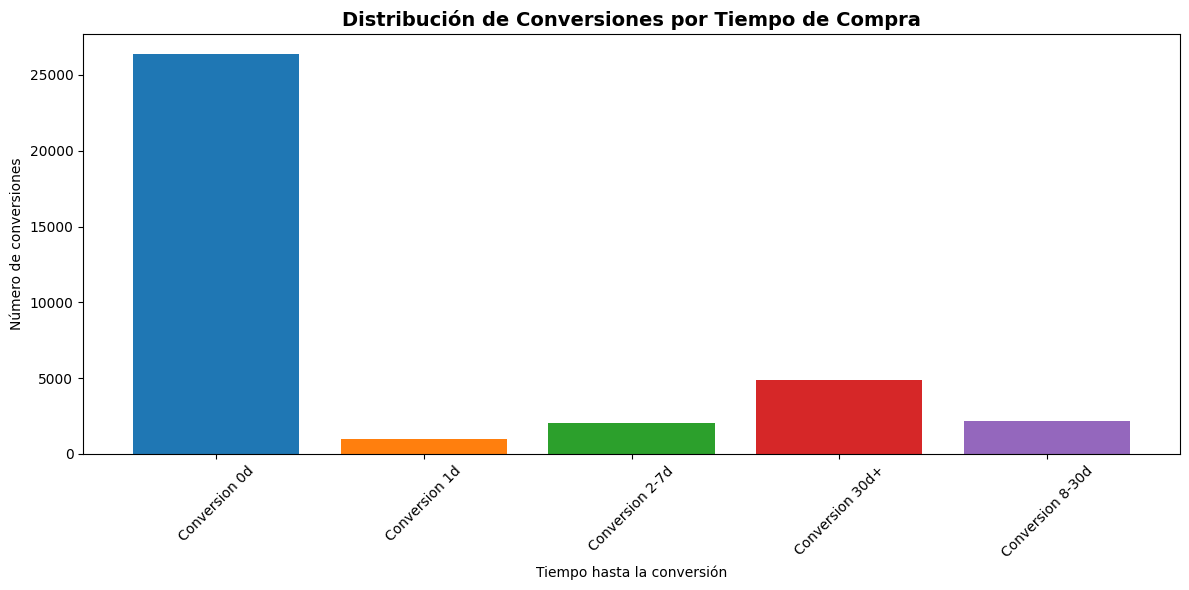

In [30]:
#Grafica de distribucion de conversiones 
plt.figure(figsize=(12, 6))

bars = plt.bar(conversion_distribution.index, 
               conversion_distribution.values,
               color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

plt.title('Distribución de Conversiones por Tiempo de Compra', 
          fontsize=14, fontweight='bold')
plt.xlabel('Tiempo hasta la conversión')
plt.ylabel('Número de conversiones')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [31]:
# empezaremos a resolver la pregunta de cuantos pedidos son diarios 
# se creara una columna de fecha para el DS orders_log
orders_log['date'] = orders_log['Buy Ts'].dt.date
# se hará el calculo de pedidos por día 
daily_orders = orders_log.groupby('date').size()
print("Pedidos por día (primeros 10):")
print(daily_orders.head(10))

Pedidos por día (primeros 10):
date
2017-06-01     96
2017-06-02    111
2017-06-03     67
2017-06-04     66
2017-06-05    161
2017-06-06    198
2017-06-07    197
2017-06-08    181
2017-06-09    131
2017-06-10     42
dtype: int64


In [32]:
# se crearan las columnas de semana y mes para calcular los pedidos de estos periodos de tiempo 
orders_log['week'] = orders_log['Buy Ts'].dt.to_period('W')
orders_log['month'] = orders_log['Buy Ts'].dt.to_period('M')
weekly_orders = orders_log.groupby('week').size()
print("Pedidos por semana (primeros 10):")
print(weekly_orders.head(10))
print("") 
monthly_orders = orders_log.groupby('month').size()
print("Pedidos por mes:")
print(monthly_orders)

Pedidos por semana (primeros 10):
week
2017-05-29/2017-06-04    340
2017-06-05/2017-06-11    938
2017-06-12/2017-06-18    343
2017-06-19/2017-06-25    371
2017-06-26/2017-07-02    460
2017-07-03/2017-07-09    477
2017-07-10/2017-07-16    636
2017-07-17/2017-07-23    716
2017-07-24/2017-07-30    381
2017-07-31/2017-08-06    314
Freq: W-SUN, dtype: int64

Pedidos por mes:
month
2017-06    2354
2017-07    2363
2017-08    1807
2017-09    3387
2017-10    5679
2017-11    5659
2017-12    6218
2018-01    4721
2018-02    5281
2018-03    5326
2018-04    3273
2018-05    4346
2018-06       1
Freq: M, dtype: int64


In [33]:
# se calculara el tamaño promedio de compra
average_order_value = orders_log['Revenue'].mean()
print(f"Tamaño promedio de compra (AOV): ${average_order_value:.2f}")

Tamaño promedio de compra (AOV): $5.00


In [34]:
# se calculara el tamaño promedio de compra mensual 
monthly_aov = orders_log.groupby('month')['Revenue'].mean()
print("Tamaño promedio de compra por mes:")
print(monthly_aov.round(2))

# se calculara el revenue mensual
monthly_revenue = orders_log.groupby('month')['Revenue'].sum()
print(f"\nRevenue total por mes:")
print(monthly_revenue.round(2))

Tamaño promedio de compra por mes:
month
2017-06    4.06
2017-07    5.31
2017-08    4.85
2017-09    5.42
2017-10    4.93
2017-11    4.78
2017-12    5.85
2018-01    4.11
2018-02    4.84
2018-03    5.41
2018-04    5.15
2018-05    4.77
2018-06    3.42
Freq: M, Name: Revenue, dtype: float64

Revenue total por mes:
month
2017-06     9557.49
2017-07    12539.47
2017-08     8758.78
2017-09    18345.51
2017-10    27987.70
2017-11    27069.93
2017-12    36388.60
2018-01    19417.13
2018-02    25560.54
2018-03    28834.59
2018-04    16858.06
2018-05    20735.98
2018-06        3.42
Freq: M, Name: Revenue, dtype: float64


In [35]:
# se calculara el LTV por usuario 
user_ltv = orders_log.groupby('Uid').agg({
    'Revenue': ['sum', 'count', 'mean'],
    'Buy Ts': ['min', 'max']
}).round(2)
#se renombraran las columnas y se acomodara el indice del DF user_ltv 
user_ltv.columns = ['total_revenue', 'total_orders', 'avg_order_value', 'first_purchase', 'last_purchase']
user_ltv = user_ltv.reset_index()

print("LTV por usuario:")
print(user_ltv.head())

LTV por usuario:
                Uid  total_revenue  total_orders  avg_order_value  \
0   313578113262317           0.55             1             0.55   
1  1575281904278712           3.05             2             1.52   
2  2429014661409475          73.33             1            73.33   
3  2464366381792757           2.44             1             2.44   
4  2551852515556206          10.99             2             5.50   

       first_purchase       last_purchase  
0 2018-01-03 21:51:00 2018-01-03 21:51:00  
1 2017-06-03 10:13:00 2017-06-03 17:39:00  
2 2017-10-11 18:33:00 2017-10-11 18:33:00  
3 2018-01-28 15:54:00 2018-01-28 15:54:00  
4 2017-11-24 10:14:00 2017-11-24 11:24:00  


In [36]:
#dejare el codigo de arriba solo para podeme ubicar en que aprte estoy 
# pero aquí comenzare a hacer el analisis a nivel cohort como se menciona en la nota del revisor 

# se agrupara por cohorte (mes de la primera visita) 
user_ltv_cohort = user_ltv.merge(first_visit[['Uid', 'first_visit_date']], on='Uid', how='left')
user_ltv_cohort['cohort_month'] = pd.to_datetime(user_ltv_cohort['first_visit_date']).dt.to_period('M')
# se agrupa por cohorte 
ltv_by_cohort = user_ltv_cohort.groupby('cohort_month').agg({
    'total_revenue': 'mean',
    'total_orders': 'mean',
    'avg_order_value': 'mean'
}).round(2)
print("LTV promedio por cohorte:")
print(ltv_by_cohort)

LTV promedio por cohorte:
              total_revenue  total_orders  avg_order_value
cohort_month                                              
2017-06               13.69          2.19             4.38
2017-07                7.25          1.44             4.79
2017-08                7.82          1.53             4.37
2017-09               11.01          1.42             4.33
2017-10                5.96          1.33             4.00
2017-11                5.73          1.40             4.06
2017-12                7.65          1.29             4.09
2018-01                4.66          1.24             3.64
2018-02                4.73          1.21             3.76
2018-03                4.85          1.25             3.76
2018-04                5.23          1.21             4.01
2018-05                4.48          1.07             4.27


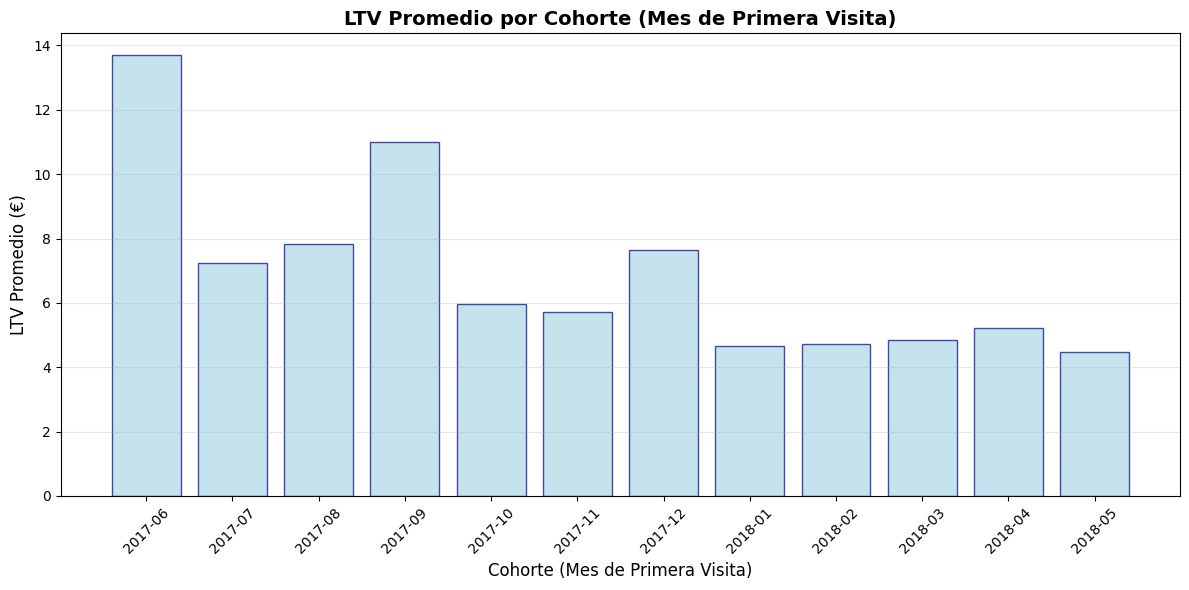

In [37]:
#creacion de la grafica de LTV promedio 
plt.figure(figsize=(12, 6))
cohort_labels = [str(cohort) for cohort in ltv_by_cohort.index]
ltv_values = ltv_by_cohort['total_revenue']
bars = plt.bar(cohort_labels, ltv_values, color='lightblue', edgecolor='navy', alpha=0.7)
plt.title('LTV Promedio por Cohorte (Mes de Primera Visita)', fontsize=14, fontweight='bold')
plt.xlabel('Cohorte (Mes de Primera Visita)', fontsize=12)
plt.ylabel('LTV Promedio (€)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
#se imprimira la informacion del DS costs para tener l info a la mano y poder trabajar con ella
print("INFORMACIÓN DEL DATASET DE COSTOS")
costs.info()

INFORMACIÓN DEL DATASET DE COSTOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB


In [39]:
# se imprimiran las estadisticas descriptivas de costos 
print("ESTADÍSTICAS DESCRIPTIVAS")
costs.describe()

ESTADÍSTICAS DESCRIPTIVAS


,source_id,costs
count,2542.000000,2542.000000
mean,4.857199,129.477427
std,3.181581,156.296628
min,1.000000,0.540000
25%,2.000000,21.945000
50%,4.000000,77.295000
75%,9.000000,170.065000
max,10.000000,1788.280000


In [40]:
# se calculara el gasto total 
total_spending = costs['costs'].sum()
print(f"Gasto total en marketing: ${total_spending:,.2f}")
# se calculara el gasto por fuente de adquisicion
spending_by_source = costs.groupby('source_id')['costs'].sum().sort_values(ascending=False)
print(f"\nGasto por fuente de adquisición:")
for source, amount in spending_by_source.items():
    print(f"Fuente {source}: ${amount:,.2f}")

Gasto total en marketing: $329,131.62

Gasto por fuente de adquisición:
Fuente 3: $141,321.63
Fuente 4: $61,073.60
Fuente 5: $51,757.10
Fuente 2: $42,806.04
Fuente 1: $20,833.27
Fuente 10: $5,822.49
Fuente 9: $5,517.49


In [41]:
# se har'a el analsis temporal de gastos de marketing
# se crearan columnas de tiempo para el DS costos 
costs['date'] = costs['dt'].dt.date
costs['month'] = costs['dt'].dt.to_period('M')
costs['week'] = costs['dt'].dt.to_period('W')

daily_costs = costs.groupby('date')['costs'].sum()
print("Gastos diarios en marketing:")
print(daily_costs.head())
print("")
weekly_costs = costs.groupby('week')['costs'].sum()
print("\nGastos semanales en marketing:")
print(weekly_costs.head().round(2))
print("")
monthly_costs = costs.groupby('month')['costs'].sum()
print("\nGastos mensuales en marketing:")
print(monthly_costs.head().round(2))

Gastos diarios en marketing:
date
2017-06-01    735.26
2017-06-02    721.19
2017-06-03    450.85
2017-06-04    761.16
2017-06-05    821.44
Name: costs, dtype: float64


Gastos semanales en marketing:
week
2017-05-29/2017-06-04    2668.46
2017-06-05/2017-06-11    5372.71
2017-06-12/2017-06-18    3462.49
2017-06-19/2017-06-25    3821.75
2017-06-26/2017-07-02    3562.67
Freq: W-SUN, Name: costs, dtype: float64


Gastos mensuales en marketing:
month
2017-06    18015.00
2017-07    18240.59
2017-08    14790.54
2017-09    24368.91
2017-10    36322.88
Freq: M, Name: costs, dtype: float64


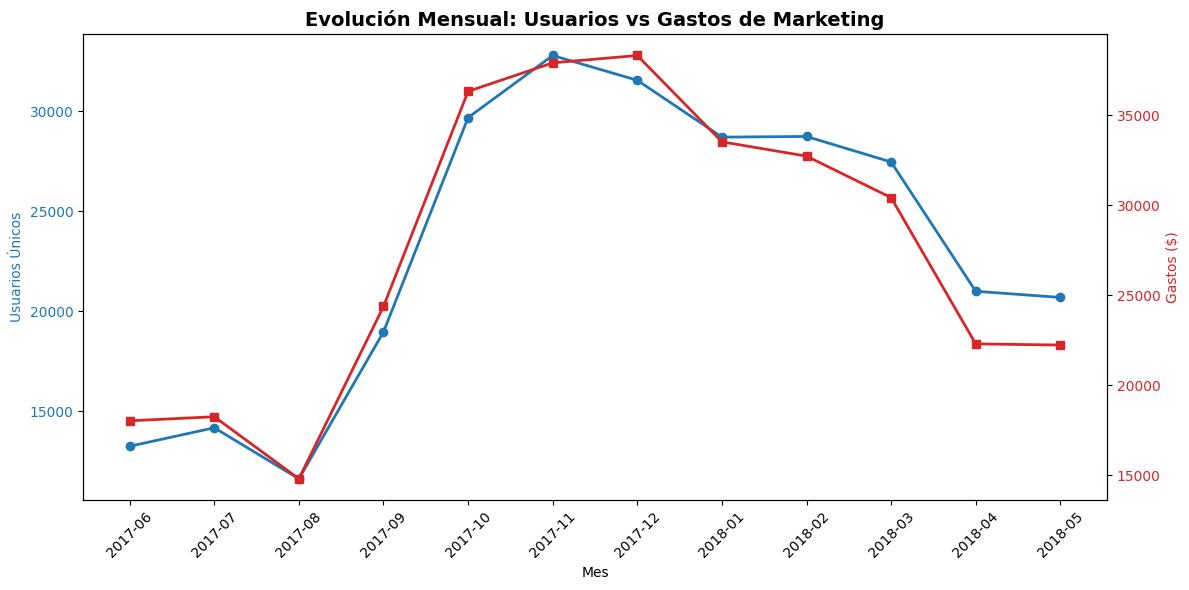

In [42]:
#Grafica de evolucion temporal de usuarios y gastos 
fig, ax1 = plt.subplots(figsize=(12, 6))


# Eje Y izquierdo - Usuarios únicos mensuales
color = 'tab:blue'
ax1.set_xlabel('Mes')
ax1.set_ylabel('Usuarios Únicos', color=color)
ax1.plot(monthly_users.index.astype(str), monthly_users.values, 
         color=color, marker='o', linewidth=2, label='Usuarios')
ax1.tick_params(axis='y', labelcolor=color)
ax1.tick_params(axis='x', rotation=45)

# Eje Y derecho - Gastos mensuales
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Gastos ($)', color=color)
ax2.plot(monthly_costs.index.astype(str), monthly_costs.values, 
         color=color, marker='s', linewidth=2, label='Gastos')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evolución Mensual: Usuarios vs Gastos de Marketing', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [43]:
# se calculara el CAC 
#primero obtendremos el numero de usuarios unicos adquiridos 
users_by_source = visits_log.groupby('Source Id')['Uid'].nunique()
print("Usuarios únicos por fuente de adquisición:")
print(users_by_source.sort_values(ascending=False))

Usuarios únicos por fuente de adquisición:
Source Id
4     83525
3     74756
5     56974
2     26245
1     18999
9      9264
10     8067
7        34
6         6
Name: Uid, dtype: int64


In [44]:
# se creara un DF para organizar mejor el CAC 
cac_analysis = pd.DataFrame({
    'total_users': users_by_source,
    'total_spending': spending_by_source
}).fillna(0)
cac_analysis['CAC'] = cac_analysis['total_spending'] / cac_analysis['total_users']

print("Análisis de CAC por fuente de adquisición:")
print(cac_analysis.round(2))

Análisis de CAC por fuente de adquisición:
    total_users  total_spending   CAC
1         18999        20833.27  1.10
2         26245        42806.04  1.63
3         74756       141321.63  1.89
4         83525        61073.60  0.73
5         56974        51757.10  0.91
6             6            0.00  0.00
7            34            0.00  0.00
9          9264         5517.49  0.60
10         8067         5822.49  0.72


In [45]:
# se hara el acalculo de ROMI 
# se hará el calculo de revenue total por fuente de adquisicion 
revenue_by_source = visits_log.merge(orders_log, on='Uid', how='inner').groupby('Source Id')['Revenue'].sum()
# se creara un DF para el analisis del ROMI y poder acomodar mejor la informacion
romi_analysis = pd.DataFrame({
    'total_users': users_by_source,
    'total_spending': spending_by_source,
    'total_revenue': revenue_by_source,
    'CAC': cac_analysis['CAC']
}).fillna(0)

# se calculara el ROMI
romi_analysis['ROMI'] = ((romi_analysis['total_revenue'] - romi_analysis['total_spending']) / romi_analysis['total_spending'] * 100)

print("Análisis ROMI por fuente de adquisición:")
print(romi_analysis.round(2))

Análisis ROMI por fuente de adquisición:
    total_users  total_spending  total_revenue   CAC      ROMI
1         18999        20833.27     2298200.17  1.10  10931.39
2         26245        42806.04     2638189.21  1.63   6063.12
3         74756       141321.63      296687.96  1.89    109.94
4         83525        61073.60      496690.17  0.73    713.26
5         56974        51757.10     1181477.14  0.91   2182.73
6             6            0.00           0.00  0.00       NaN
7            34            0.00           1.22  0.00       inf
9          9264         5517.49       36342.25  0.60    558.67
10         8067         5822.49       14619.23  0.72    151.08


In [46]:
# crearemos graficas para comparar los resultados anteriores y se puedan entender de mejor manera
# se limpiara el analisis de romi paraevitar datos infinitos o nulos
romi_clean = romi_analysis[romi_analysis['ROMI'].notna() & (romi_analysis['ROMI'] != float('inf'))]
display(romi_clean.head())

,total_users,total_spending,total_revenue,CAC,ROMI
1,18999,20833.27,2.298200e+06,1.096546,10931.394351
2,26245,42806.04,2.638189e+06,1.631017,6063.123732
3,74756,141321.63,2.966880e+05,1.890439,109.938111
4,83525,61073.60,4.966902e+05,0.731201,713.264930
5,56974,51757.10,1.181477e+06,0.908434,2182.734427


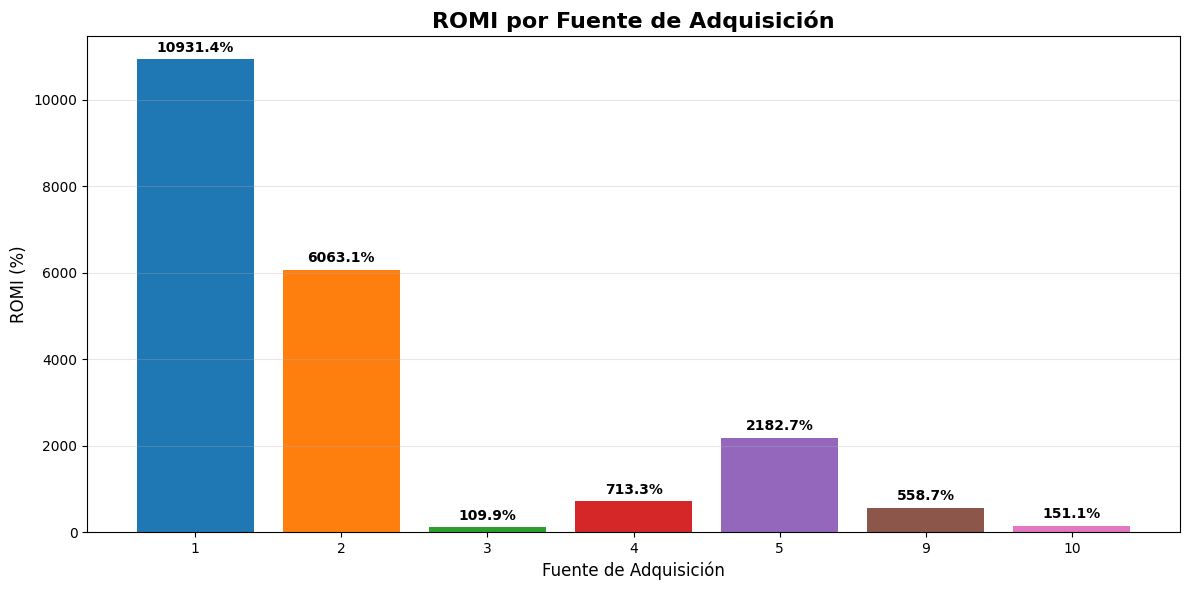

In [47]:
# se creara la grafica de barras
plt.figure(figsize=(12, 6))
plt.bar(romi_clean.index.astype(str), romi_clean['ROMI'], 
        color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2'])
plt.title('ROMI por Fuente de Adquisición', fontsize=16, fontweight='bold')
plt.xlabel('Fuente de Adquisición', fontsize=12)
plt.ylabel('ROMI (%)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(romi_clean['ROMI']):
    plt.text(i, v + max(romi_clean['ROMI'])*0.01, f'{v:.1f}%', 
             ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

In [48]:
# se hará el calculo de gastos por dispositivo
spending_by_source_dict = spending_by_source.to_dict()
#Se calcularan usuarios únicos por fuente
users_per_source = visits_log.groupby('Source Id')['Uid'].nunique()
# Se creara un diccionario de CAC por fuente
cac_by_source = {}
for source_id in spending_by_source.index:
    if source_id in users_per_source.index:
        cac_by_source[source_id] = spending_by_source[source_id] / users_per_source[source_id]
    else:
        cac_by_source[source_id] = 0
#se asigna el gasto en cada visita segun su fuente 
visits_with_spending = visits_log.copy()
visits_with_spending['source_cac'] = visits_with_spending['Source Id'].map(cac_by_source).fillna(0)
#se calcula ahora por dispositivo 
device_analysis = visits_log.merge(orders_log, on='Uid', how='left')
users_by_device = visits_log.groupby('Device')['Uid'].nunique()
spending_by_device = visits_with_spending.groupby('Device')['source_cac'].sum()
revenue_by_device = device_analysis.groupby('Device')['Revenue'].sum().fillna(0)
print("Usuarios por dispositivo:")
print(users_by_device)
print("\nGastos por dispositivo:")
print(spending_by_device.round(2))



Usuarios por dispositivo:
Device
desktop    164523
touch       71345
Name: Uid, dtype: int64

Gastos por dispositivo:
Device
desktop    317199.50
touch      110088.94
Name: source_cac, dtype: float64


In [49]:
# se hara el analisis completo por dispositivo 
device_romi = pd.DataFrame({
    'users': users_by_device,
    'spending': spending_by_device,
    'revenue': revenue_by_device
}).fillna(0)
#se calcula CAC y ROMI por dispositivo 
device_romi['CAC'] = device_romi['spending'] / device_romi['users']
device_romi['ROMI'] = ((device_romi['revenue'] - device_romi['spending']) / device_romi['spending'] * 100)
print("Análisis completo por dispositivo:")
print(device_romi.round(2))

Análisis completo por dispositivo:
          users   spending     revenue   CAC     ROMI
Device                                               
desktop  164523  317199.50  6447893.99  1.93  1932.76
touch     71345  110088.94   514313.36  1.54   367.18


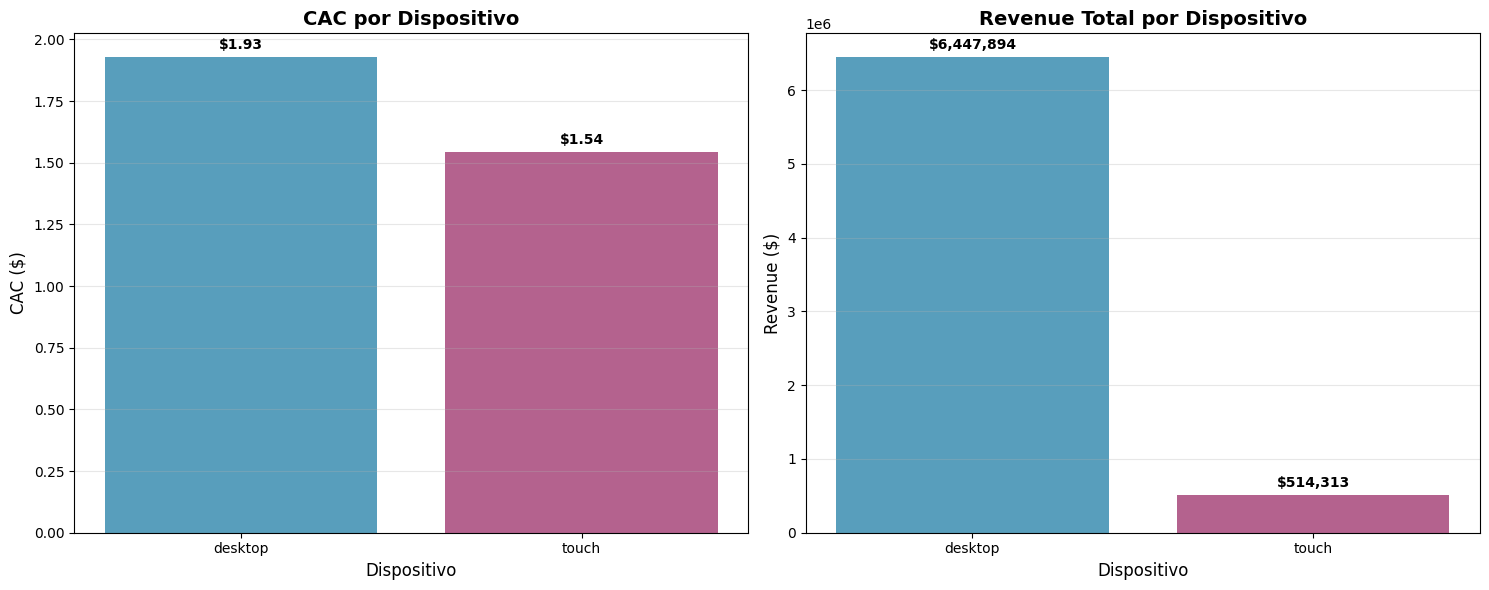

In [50]:
# se creara un gráfico comparativo de CAC vs Revenue por dispositivo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: CAC por dispositivo
devices = device_romi.index
cac_values = device_romi['CAC']
colors = ['#2E86AB', '#A23B72']  

bars1 = ax1.bar(devices, cac_values, color=colors, alpha=0.8)
ax1.set_title('CAC por Dispositivo', fontsize=14, fontweight='bold')
ax1.set_xlabel('Dispositivo', fontsize=12)
ax1.set_ylabel('CAC ($)', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

for bar, value in zip(bars1, cac_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'${value:.2f}', ha='center', va='bottom', fontweight='bold')

# Gráfico 2: Revenue por dispositivo
revenue_values = device_romi['revenue']
bars2 = ax2.bar(devices, revenue_values, color=colors, alpha=0.8)
ax2.set_title('Revenue Total por Dispositivo', fontsize=14, fontweight='bold')
ax2.set_xlabel('Dispositivo', fontsize=12)
ax2.set_ylabel('Revenue ($)', fontsize=12)
ax2.grid(axis='y', alpha=0.3)


for bar, value in zip(bars2, revenue_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(revenue_values)*0.01, 
             f'${value:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()